In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import sys
from pathlib import Path
from src.run_model import run_analysis
from src.config import CSV_PATH
from src.preprocess import load_and_prep_data


================ CLUSTERING SANITY CHECK ================
Regime: controlled
Features used: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Silhouette Score: 0.404
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 332 shots (33.2%)
  Cluster 1: 373 shots (37.3%)
  Cluster 2: 161 shots (16.1%)
  Cluster 3: 133 shots (13.3%)

--- Cluster Means ---
               PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES      ETAU
Cluster_Label                                                                            
2               3.477672  37.583082 -0.000366  1.961619  1.516418  5.724205e+13  0.045923
1               4.149743  39.533137  1.948345  1.991352  0.210047  6.559004e+13  0.042155
0               5.583279  38.393384  1.962578  1.790524  1.830177  7.893287e+13  0.037482
3               2.004975  42.550452  1.489082  0.086901  0.428992  4.498990e+13  0.036148


/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


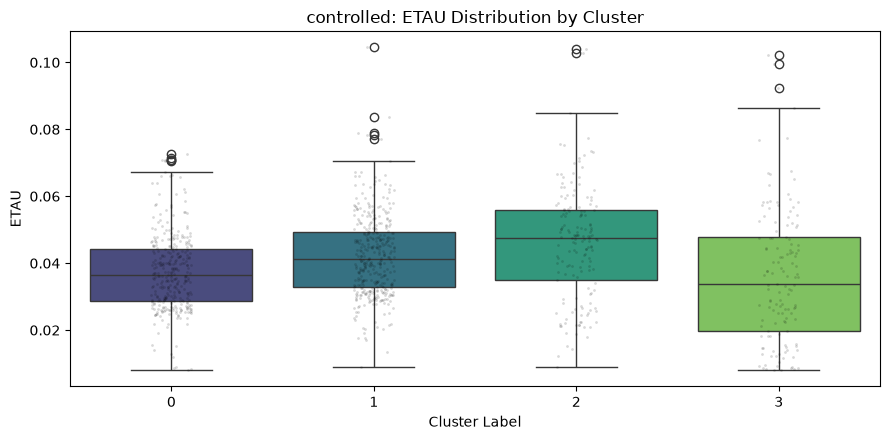


ETAU prediction using KMeans clusters: R^2 = 0.650
ETAU prediction using KMeans clusters: RMSE = 0.008


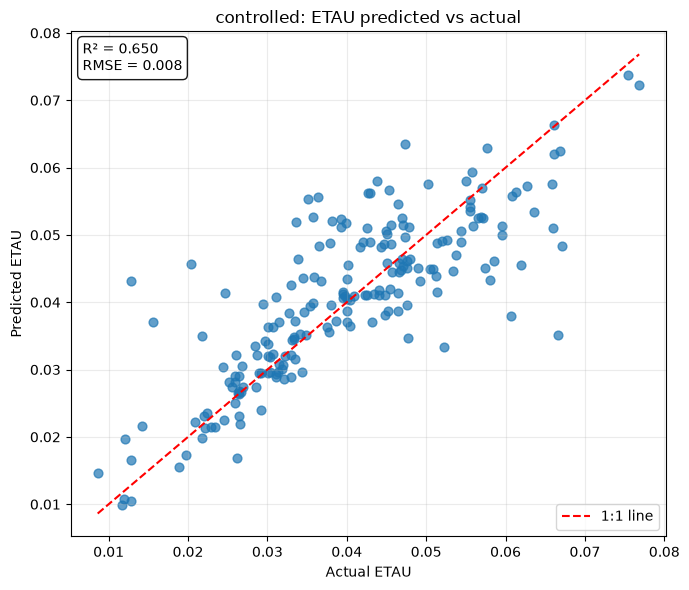

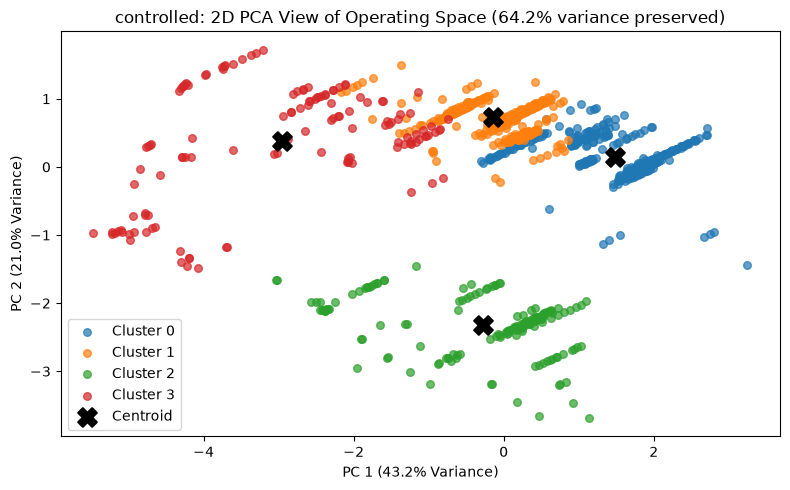


PCA component loadings:
     PBEAM_TOT      BZXR   PBEAM_A   PBEAM_B   PBEAM_C       NES
PC1   0.576492 -0.380970  0.191605  0.394523  0.377011  0.433614
PC2   0.119087  0.298761  0.812328 -0.120882 -0.417629  0.218307
================ CLUSTERING SANITY CHECK ================
Regime: secondary
Features used: ['PBEAM_TOT', 'BZXR', 'TE', 'VBEAM_A', 'VBEAM_B', 'VBEAM_C']
Silhouette Score: 0.417
 -> Assessment: Fair structure; expected overlap across continuous plasma regimes.

Cluster Size Balance:
  Cluster 0: 304 shots (30.4%)
  Cluster 1: 161 shots (16.1%)
  Cluster 2: 367 shots (36.7%)
  Cluster 3: 167 shots (16.7%)

--- Cluster Means ---
               PBEAM_TOT       BZXR          TE    VBEAM_A    VBEAM_B    VBEAM_C      ETAU
Cluster_Label                                                                             
1               3.477672  37.583082  943.181135  -0.049642  89.248340  71.419399  0.045923
0               3.952934  39.440114  887.122043  89.492431  89.884650   1.1753

/Users/aldensantoso/Documents/plasma_research/ML Project/src/run_model.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=work, x="Cluster_Label", y=target_col, palette="viridis")


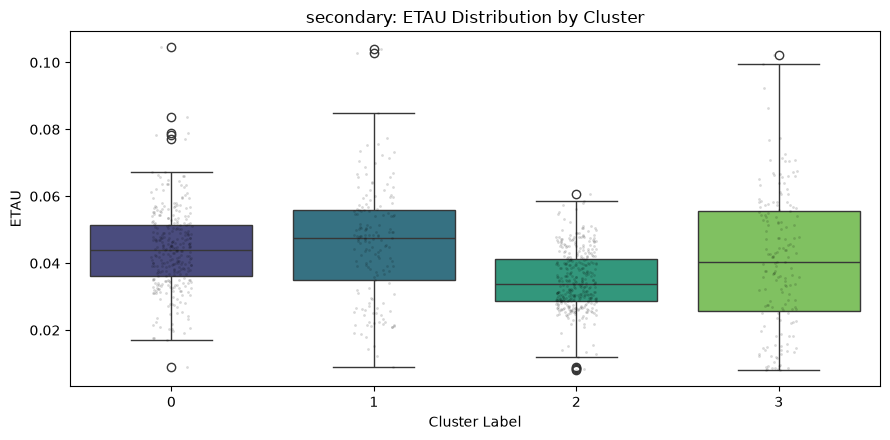


ETAU prediction using KMeans clusters: R^2 = 0.706
ETAU prediction using KMeans clusters: RMSE = 0.007


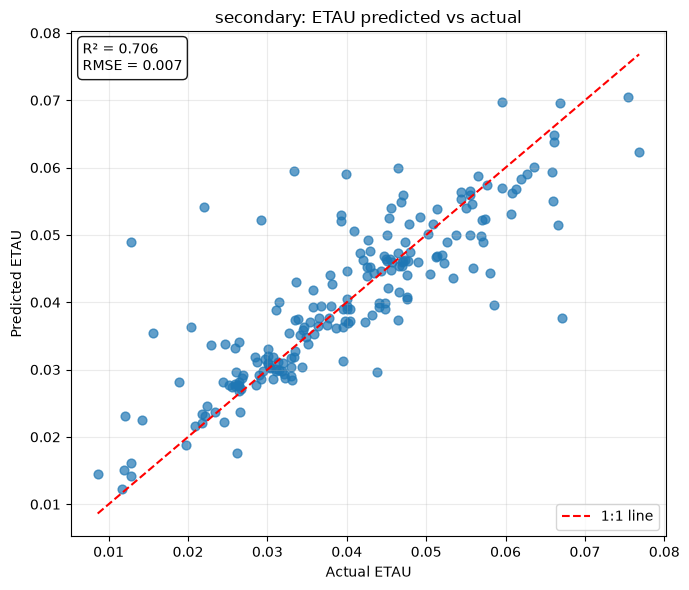

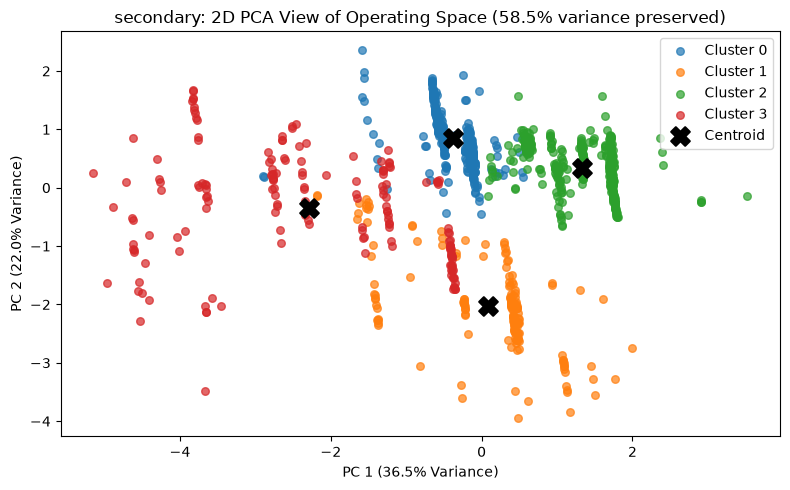


PCA component loadings:
     PBEAM_TOT      BZXR        TE   VBEAM_A   VBEAM_B   VBEAM_C
PC1   0.629139 -0.430914  0.048426  0.134475  0.465985  0.425355
PC2   0.206538  0.213726 -0.509633  0.695688  0.126739 -0.389733


In [2]:

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES",
]

mode_features = [
    "PBEAM_TOT",
    "BZXR",
    "TE",
    "VBEAM_A",
    "VBEAM_B",
    "VBEAM_C",
]

analysis_control = run_analysis(
    feature_cols=controlled_features,
    regime_name="controlled",
)

analysis_secondary = run_analysis(
    feature_cols=mode_features,
    regime_name="secondary",
)

In [3]:
# Cell 1: load and prepare only the controlled variables


PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

controlled_features = [
    "PBEAM_TOT",
    "BZXR",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C",
    "NES"
]

df_clean_controlled = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=controlled_features,
)

print("Rows:", len(df_clean_controlled))
print("Controlled feature list:", controlled_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['PBEAM_TOT', 'BZXR', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C', 'NES']
Target column: ETAU


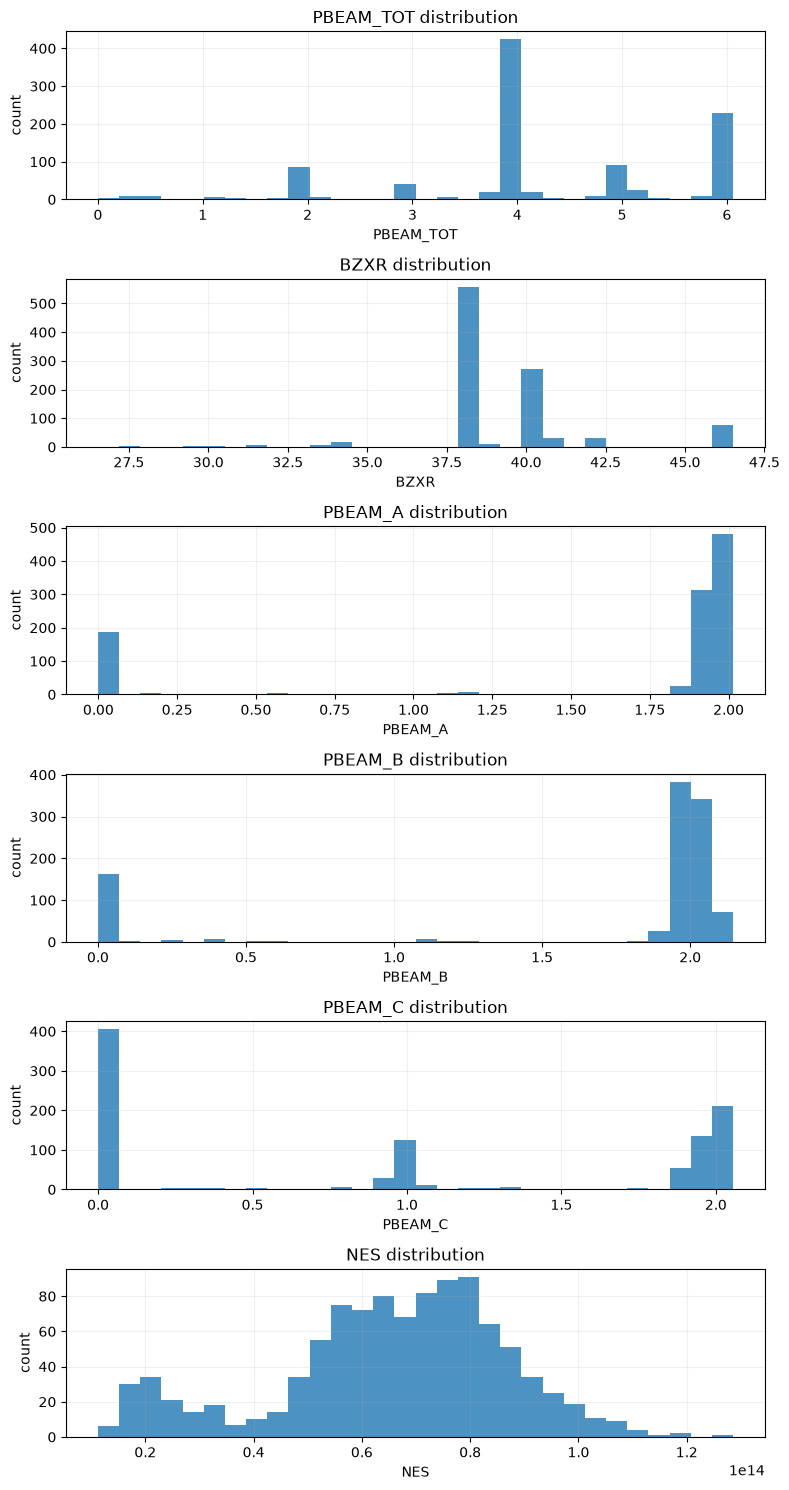

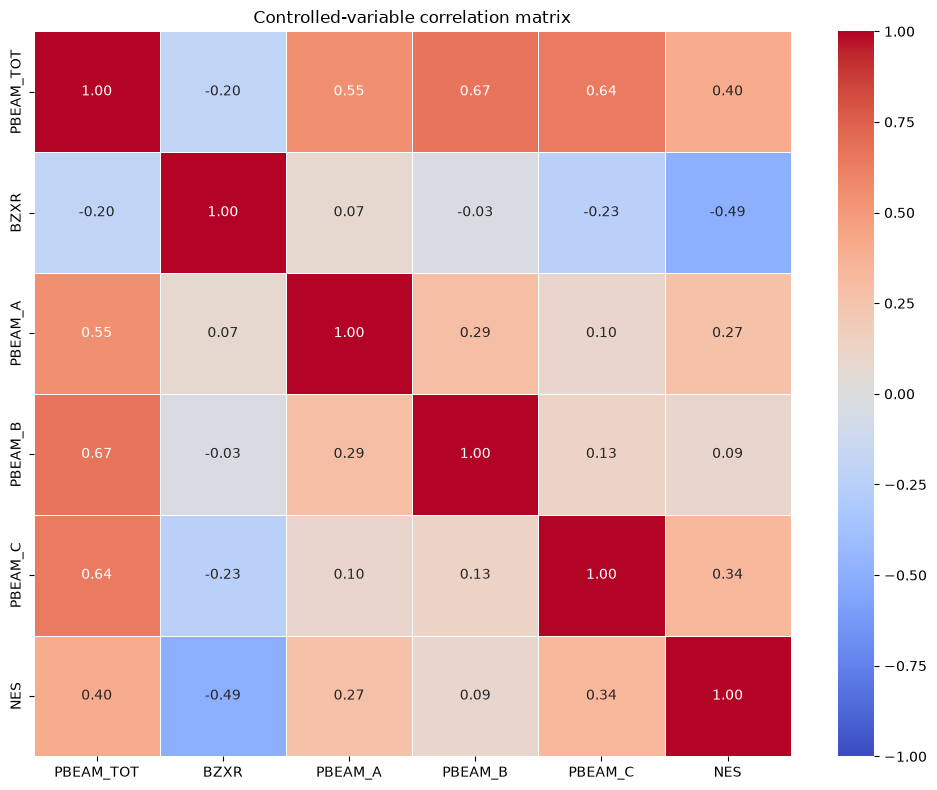

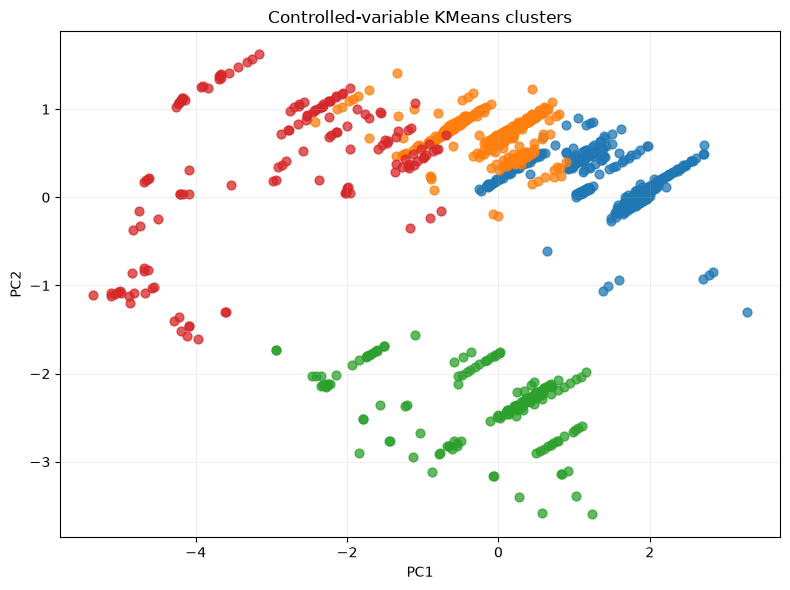

         PBEAM_TOT       BZXR   PBEAM_A   PBEAM_B   PBEAM_C           NES  \
Cluster                                                                     
0         5.585592  38.391067  1.962471  1.791832  1.831288  7.887373e+13   
1         4.150072  39.561745  1.948406  1.991862  0.209805  6.522777e+13   
2         3.477159  37.619842 -0.000368  1.961965  1.515562  5.747248e+13   
3         1.997204  42.595986  1.506184  0.079163  0.411856  4.570407e+13   

             ETAU  
Cluster            
0        0.037277  
1        0.042064  
2        0.046880  
3        0.039645  


In [4]:
# Cell 2: variable distributions, correlation matrix, and controlled-feature KMeans summary


# 1) distributions for the chosen controlled variables
fig, axes = plt.subplots(len(controlled_features), 1, figsize=(8, 2.5 * len(controlled_features)))

if len(controlled_features) == 1:
    axes = [axes]

for ax, col in zip(axes, controlled_features):
    df_clean_controlled[col].dropna().plot(kind="hist", bins=30, ax=ax, alpha=0.8)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 2) correlation matrix for the chosen controlled variables
corr = df_clean_controlled[controlled_features].corr(method = "spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Controlled-variable correlation matrix")
plt.tight_layout()
plt.show()

# 3) canonical KMeans clustering summary for the chosen controlled variables
X = df_clean_controlled[controlled_features].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=4, random_state=42, n_init=25)
labels = km.fit_predict(X_scaled)

# plot KMeans clusters in PCA space
fig, ax = plt.subplots(figsize=(8, 6))
for cl in np.unique(labels):
    mask = labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.75)

ax.set_title("Controlled-variable KMeans clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# summary table by cluster
cluster_summary = (
    df_clean_controlled.loc[X.index]
    .assign(Cluster=labels)
    .groupby("Cluster")[controlled_features + ["ETAU"]]
    .mean()
)

print(cluster_summary)

In [8]:
PROJECT_ROOT = Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

mode_features = [
    "TOTPWR",
    "AVGMODEN",
    "AVGMODEF",
    "CONDE",
    "PBEAM_A",
    "PBEAM_B",
    "PBEAM_C"
]

target = ['ETAU']

df_clean_mode = load_and_prep_data(
    str(CSV_PATH),
    feature_cols=mode_features,
)

print("Rows:", len(df_clean_mode))
print("Controlled feature list:", mode_features)
print("Target column:", "ETAU")

Rows: 1021
Controlled feature list: ['TOTPWR', 'AVGMODEN', 'AVGMODEF', 'CONDE', 'PBEAM_A', 'PBEAM_B', 'PBEAM_C']
Target column: ETAU


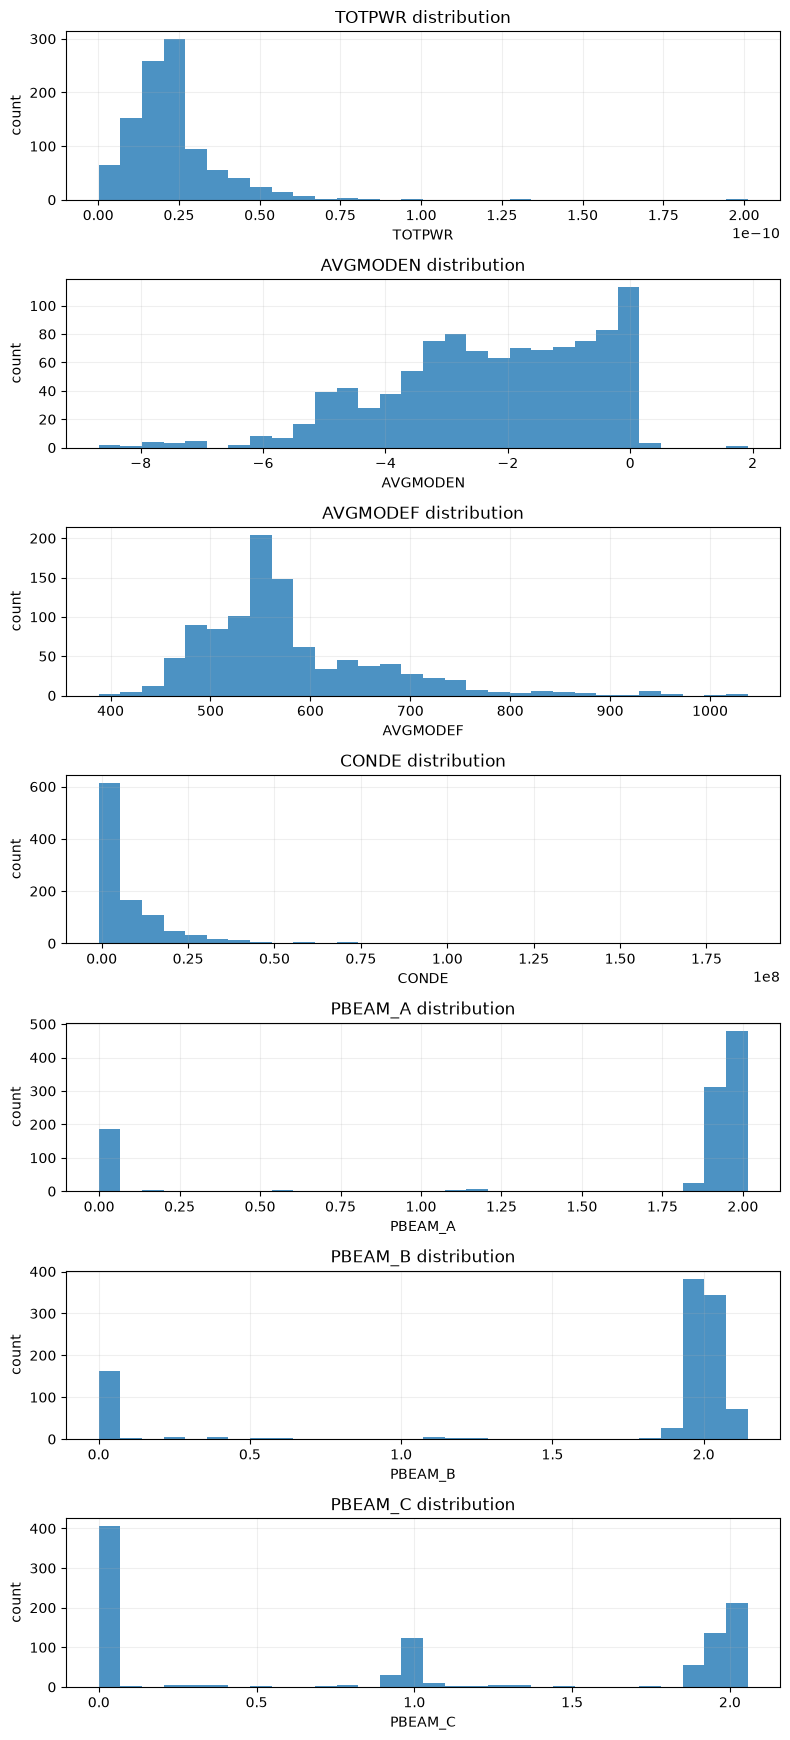

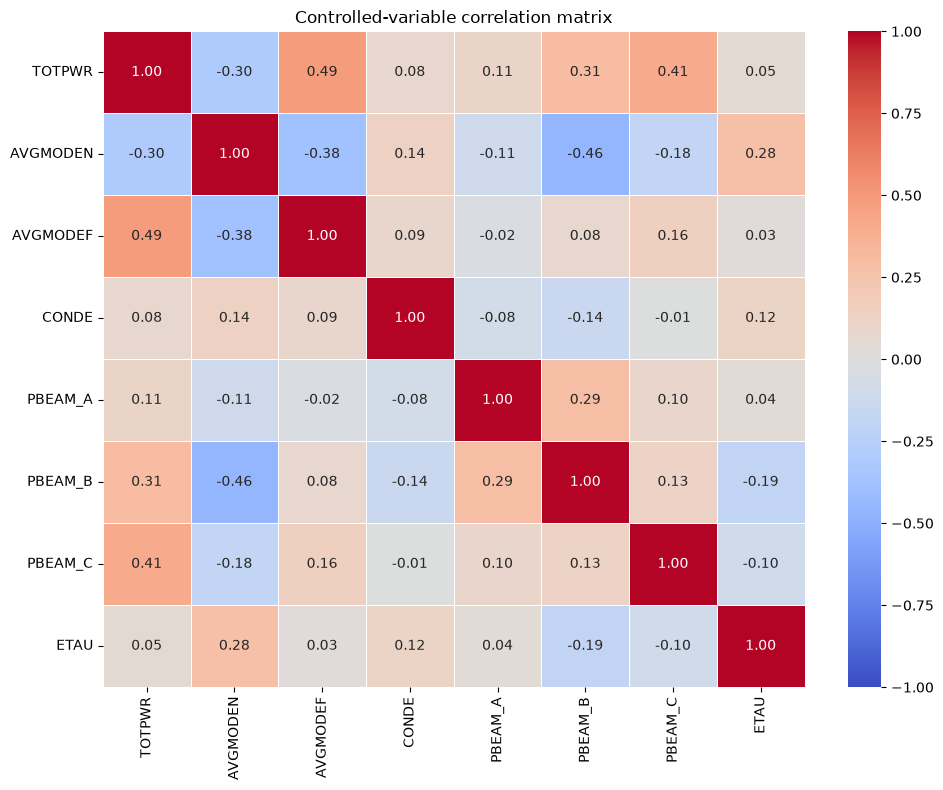

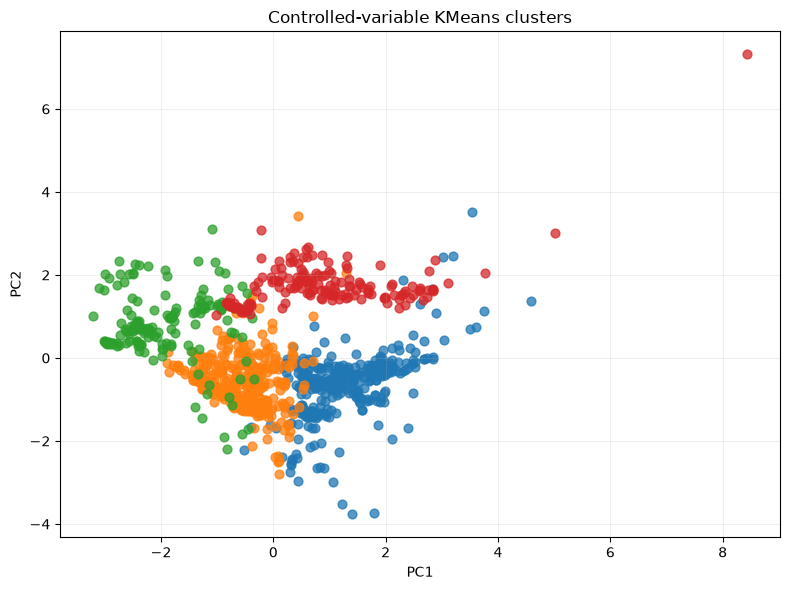

               TOTPWR  AVGMODEN    AVGMODEF         CONDE   PBEAM_A   PBEAM_B  \
Cluster                                                                         
0        2.932322e-11 -3.878793  635.033292  7.349089e+06  1.909362  1.920559   
1        1.767799e-11 -2.117794  543.450758  7.614970e+06  1.950020  1.996375   
2        1.228906e-11 -0.580521  529.090212  1.037706e+07  1.678882  0.094339   
3        3.190549e-11 -1.314666  593.991220  1.232128e+07  0.011327  1.967187   

          PBEAM_C      ETAU  
Cluster                      
0        1.589444  0.033712  
1        0.329841  0.042437  
2        0.765788  0.045109  
3        1.509459  0.046715  


In [9]:
# Cell 2: variable distributions, correlation matrix, and controlled-feature KMeans summary


# 1) distributions for the chosen controlled variables
fig, axes = plt.subplots(len(mode_features), 1, figsize=(8, 2.5 * len(mode_features)))

if len(mode_features) == 1:
    axes = [axes]

for ax, col in zip(axes, mode_features):
    df_clean_mode[col].dropna().plot(kind="hist", bins=30, ax=ax, alpha=0.8)
    ax.set_title(f"{col} distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("count")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# 2) correlation matrix for the chosen controlled variables
corr = df_clean_mode[mode_features + target].corr(method = "spearman")

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5,
    ax=ax
)
ax.set_title("Controlled-variable correlation matrix")
plt.tight_layout()
plt.show()

# 3) canonical KMeans clustering summary for the chosen controlled variables
X = df_clean_mode[mode_features].copy()
X = X.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

km = KMeans(n_clusters=4, random_state=42, n_init=25)
labels = km.fit_predict(X_scaled)

# plot KMeans clusters in PCA space
fig, ax = plt.subplots(figsize=(8, 6))
for cl in np.unique(labels):
    mask = labels == cl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.75)

ax.set_title("Controlled-variable KMeans clusters")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# summary table by cluster
cluster_summary = (
    df_clean_mode.loc[X.index]
    .assign(Cluster=labels)
    .groupby("Cluster")[mode_features + ["ETAU"]]
    .mean()
)

print(cluster_summary)